In [16]:

import pandas as pd
import numpy as np
import joblib
import time
import warnings
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from scipy.stats import randint
warnings.filterwarnings("ignore")
RND = 42

In [ ]:
train = pd.read_csv(
    "/media/lazy/28481E65481E31D4/Placement Drive/AI ML Position/Dataset/train_preprocessed.csv")
test = pd.read_csv(
    "/media/lazy/28481E65481E31D4/Placement Drive/AI ML Position/Dataset/test_preprocessed.csv")

In [18]:
print("Train shape:", train.shape)
print("Test shape: ", test.shape)
print("Train columns:\n", train.columns.tolist())

Train shape: (891, 22)
Test shape:  (418, 20)
Train columns:
 ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Cabin_Known', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_U', 'FamilySize', 'IsAlone']


In [19]:
drop_cols = ['PassengerId', 'Name', 'Cabin_Deck']
train = train.drop(
    columns=[c for c in drop_cols if c in train.columns], errors='ignore')
test = test.drop(
    columns=[c for c in drop_cols if c in test.columns], errors='ignore')

# Convert bools to ints (so get_dummies/ML plays nicely)
for df in (train, test):
    bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
    for c in bool_cols:
        df[c] = df[c].astype(int)

# Use all columns except Survived as features
features = [c for c in train.columns if c != 'Survived']
print("Using features:", features)

# Build X, y (we will do get_dummies + impute next)
X_full = train[features].copy()
y_full = train['Survived'].copy()

Using features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Cabin_Known', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_U', 'FamilySize', 'IsAlone']


In [20]:
num_cols = X_full.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_full.select_dtypes(
    include=['object', 'category']).columns.tolist()

print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)

# numeric imputer
num_imputer = SimpleImputer(strategy='median')
if num_cols:
    X_full[num_cols] = num_imputer.fit_transform(X_full[num_cols])
    # if test has these cols, apply as well
    if set(num_cols).issubset(set(test.columns)):
        test[num_cols] = num_imputer.transform(test[num_cols])

# categorical impute (mode)
for c in cat_cols:
    mode_val = X_full[c].mode(dropna=True)
    fill = mode_val.iloc[0] if not mode_val.empty else "Missing"
    X_full[c] = X_full[c].fillna(fill)
    if c in test.columns:
        test[c] = test[c].fillna(fill)

# One-hot encode categorical columns (on concatenation to ensure consistent columns)
if cat_cols:
    combined = pd.concat([X_full[cat_cols], test[cat_cols]],
                         axis=0, ignore_index=True)
    combined_dummies = pd.get_dummies(
        combined, columns=cat_cols, prefix=cat_cols, drop_first=False)
    # split back
    X_ohe = combined_dummies.iloc[:len(X_full)].set_index(X_full.index)
    test_ohe = combined_dummies.iloc[len(X_full):].set_index(test.index)
    # drop original cat cols and concat
    X_full = pd.concat([X_full.drop(columns=cat_cols), X_ohe], axis=1)
    test_features_df = pd.concat(
        [test.drop(columns=cat_cols), test_ohe], axis=1)
else:
    test_features_df = test.copy()

# Align columns train/test (feature parity)
X_full, X_test = X_full.align(
    test_features_df, join='left', axis=1, fill_value=0)

print("After encoding/alignment -> X shape:",
      X_full.shape, "X_test shape:", X_test.shape)

Numeric cols: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin_Known', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_U', 'FamilySize', 'IsAlone']
Categorical cols: ['Embarked']
After encoding/alignment -> X shape: (891, 21) X_test shape: (418, 21)


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.20, random_state=RND, stratify=y_full)
print("Train split:", X_train.shape, X_val.shape)

# Helper to evaluate
def evaluate(name, model, Xval, yval):
    ypred = model.predict(Xval)
    acc = accuracy_score(yval, ypred)
    prec = precision_score(yval, ypred)
    rec = recall_score(yval, ypred)
    f1 = f1_score(yval, ypred)
    cm = confusion_matrix(yval, ypred)
    print(f"\n== {name} evaluation ==")
    print("Accuracy: %.4f  Precision: %.4f  Recall: %.4f  F1: %.4f" %
          (acc, prec, rec, f1))
    print("Confusion matrix:\n", cm)
    print(classification_report(yval, ypred))
    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, cm=cm)

Train split: (712, 21) (179, 21)


In [ ]:
print("\nTraining baseline Logistic Regression...")
lr_baseline = LogisticRegression(
    random_state=RND, solver='liblinear', max_iter=200)
lr_baseline.fit(X_train, y_train)
lr_base_metrics = evaluate(
    "LogisticRegression (baseline)", lr_baseline, X_val, y_val)

print("\nTraining baseline Random Forest...")
rf_baseline = RandomForestClassifier(
    random_state=RND, n_jobs=-1, n_estimators=100)
rf_baseline.fit(X_train, y_train)
rf_base_metrics = evaluate("RandomForest (baseline)",
                           rf_baseline, X_val, y_val)


Training baseline Logistic Regression...

== LogisticRegression (baseline) evaluation ==
Accuracy: 0.8156  Precision: 0.8000  Recall: 0.6957  F1: 0.7442
Confusion matrix:
 [[98 12]
 [21 48]]
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179


Training baseline Random Forest...

== RandomForest (baseline) evaluation ==
Accuracy: 0.7989  Precision: 0.7705  Recall: 0.6812  F1: 0.7231
Confusion matrix:
 [[96 14]
 [22 47]]
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       110
           1       0.77      0.68      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)

# ---------- Logistic Regression Grid ----------
print("\nTuning Logistic Regression (GridSearchCV)...")
lr_param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'solver': ['liblinear']  
}
lr = LogisticRegression(random_state=RND, max_iter=500)
lr_gs = GridSearchCV(lr, lr_param_grid, cv=cv,
                     scoring='f1', n_jobs=-1, verbose=1)
start = time.time()
lr_gs.fit(X_train, y_train)
print("GridSearch done in %.1f s" % (time.time()-start))
best_lr = lr_gs.best_estimator_
print("Best LR params:", lr_gs.best_params_)
lr_tuned_metrics = evaluate(
    "LogisticRegression (tuned)", best_lr, X_val, y_val)

# ---------- Random Forest Randomized ----------
print("\nTuning Random Forest (RandomizedSearchCV)...")
rf = RandomForestClassifier(random_state=RND, n_jobs=-1)
rf_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': [None] + list(range(4, 21, 4)),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 6),
    'max_features': ['auto', 'sqrt', 0.5, 0.75]
}
rf_rand = RandomizedSearchCV(
    rf, rf_dist, n_iter=40, cv=cv, scoring='f1', random_state=RND, n_jobs=-1, verbose=1)
start = time.time()
rf_rand.fit(X_train, y_train)
print("RandomizedSearch done in %.1f s" % (time.time()-start))
best_rf = rf_rand.best_estimator_
print("Best RF params:", rf_rand.best_params_)
rf_tuned_metrics = evaluate("RandomForest (tuned)", best_rf, X_val, y_val)


Tuning Logistic Regression (GridSearchCV)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
GridSearch done in 23.7 s
Best LR params: {'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}

== LogisticRegression (tuned) evaluation ==
Accuracy: 0.8156  Precision: 0.8000  Recall: 0.6957  F1: 0.7442
Confusion matrix:
 [[98 12]
 [21 48]]
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179


Tuning Random Forest (RandomizedSearchCV)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
RandomizedSearch done in 73.4 s
Best RF params: {'max_depth': 12, 'max_features': 0.75, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 234}

== RandomForest (tuned) evaluation ==
Accuracy: 0.7933  Preci

In [24]:
import pprint
print("\n\n=== Summary comparison (validation set) ===")
pp = pprint.PrettyPrinter(indent=2)
print("LogisticRegression baseline metrics:")
pp.pprint(lr_base_metrics)
print("LogisticRegression tuned metrics:")
pp.pprint(lr_tuned_metrics)
print("\nRandomForest baseline metrics:")
pp.pprint(rf_base_metrics)
print("RandomForest tuned metrics:")
pp.pprint(rf_tuned_metrics)



=== Summary comparison (validation set) ===
LogisticRegression baseline metrics:
{ 'accuracy': 0.8156424581005587,
  'cm': array([[98, 12],
       [21, 48]]),
  'f1': 0.7441860465116279,
  'precision': 0.8,
  'recall': 0.6956521739130435}
LogisticRegression tuned metrics:
{ 'accuracy': 0.8156424581005587,
  'cm': array([[98, 12],
       [21, 48]]),
  'f1': 0.7441860465116279,
  'precision': 0.8,
  'recall': 0.6956521739130435}

RandomForest baseline metrics:
{ 'accuracy': 0.7988826815642458,
  'cm': array([[96, 14],
       [22, 47]]),
  'f1': 0.7230769230769231,
  'precision': 0.7704918032786885,
  'recall': 0.6811594202898551}
RandomForest tuned metrics:
{ 'accuracy': 0.7932960893854749,
  'cm': array([[98, 12],
       [25, 44]]),
  'f1': 0.704,
  'precision': 0.7857142857142857,
  'recall': 0.6376811594202898}


In [ ]:
if hasattr(best_rf, "feature_importances_"):
    importances = pd.Series(best_rf.feature_importances_,
                            index=X_train.columns).sort_values(ascending=False)
    print("\nTop 15 feature importances (RF):\n", importances.head(15))

if hasattr(best_lr, "coef_"):
    coefs = pd.Series(best_lr.coef_.ravel(),
                      index=X_train.columns).abs().sort_values(ascending=False)
    print("\nTop 15 absolute coefficients (LR):\n", coefs.head(15))


Top 15 feature importances (RF):
 Sex            0.336825
Age            0.195276
Fare           0.190088
Pclass         0.079495
FamilySize     0.039437
Deck_U         0.032907
Cabin_Known    0.025212
SibSp          0.020386
Embarked_S     0.017329
Parch          0.013560
Deck_E         0.008142
Embarked_C     0.008026
Embarked_Q     0.006628
Deck_C         0.006487
IsAlone        0.006414
dtype: float64

Top 15 absolute coefficients (LR):
 Sex            2.519655
Deck_E         0.855726
Cabin_Known    0.815617
Pclass         0.697124
Deck_G         0.691656
Deck_F         0.663712
Deck_D         0.632363
Embarked_Q     0.597219
SibSp          0.504381
IsAlone        0.477441
Embarked_C     0.365184
Parch          0.321004
Deck_T         0.243633
Deck_C         0.208933
Deck_B         0.165454
dtype: float64


In [26]:
joblib.dump(best_lr, "best_logistic_regression.joblib")
joblib.dump(best_rf, "best_random_forest.joblib")
print("\nSaved best_logistic_regression.joblib and best_random_forest.joblib")


Saved best_logistic_regression.joblib and best_random_forest.joblib


Loaded train: (891, 22)
Feature candidate count: 25
Numeric cols: ['PassengerId', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin_Known', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_U', 'FamilySize', 'IsAlone', 'Age_missing', 'Fare_log', 'Fare_bin']
Categorical cols: ['Embarked', 'Title', 'Age_band']
Final X_all shape after encoding: (891, 37)
Train/val shapes: (712, 37) (179, 37)
Loaded model: best_lr from best_logistic_regression.joblib
Loaded model: best_rf_tuned from best_random_forest.joblib
Loaded model: rf_old from random_forest_best.joblib

== Evaluating model: best_lr ==
Accuracy: 0.8156, Precision: 0.8000, Recall: 0.6957, F1: 0.7442
Confusion matrix:
 [[98 12]
 [21 48]]
Classification report:
               precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg      

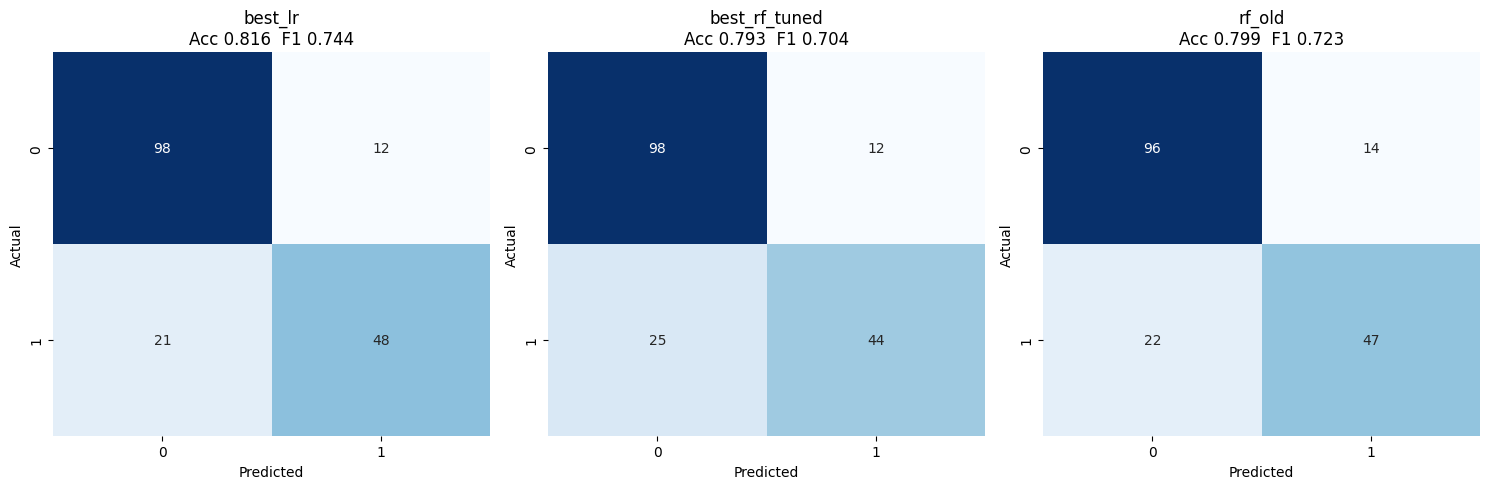

Saved confusion matrices to confusion_matrices.png

--- Top features for model: best_lr ---
Top LR absolute coefficients:
 Sex            2.519655
Deck_E         0.855726
Cabin_Known    0.815617
Pclass         0.697124
Deck_G         0.691656
Deck_F         0.663712
Deck_D         0.632363
Embarked_Q     0.597219
SibSp          0.504381
IsAlone        0.477441
Embarked_C     0.365184
Parch          0.321004
Deck_T         0.243633
Deck_C         0.208933
Deck_B         0.165454
Deck_U         0.147663
FamilySize     0.137895
Age            0.035568
Deck_A         0.026507
Fare           0.002964
dtype: float64

--- Top features for model: best_rf_tuned ---
Top RF importances:
 Sex            0.336825
Age            0.195276
Fare           0.190088
Pclass         0.079495
FamilySize     0.039437
Deck_U         0.032907
Cabin_Known    0.025212
SibSp          0.020386
Embarked_S     0.017329
Parch          0.013560
Deck_E         0.008142
Embarked_C     0.008026
Embarked_Q     0.006628
De

In [ ]:
# evaluate_models_on_validation.py
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- CONFIG ----------
TRAIN_PATH = "/media/lazy/28481E65481E31D4/Placement Drive/AI ML Position/train_preprocessed.csv"
MODEL_FILES = {
    "best_lr": "best_logistic_regression.joblib",
    "best_rf_tuned": "best_random_forest.joblib",
    "rf_old": "random_forest_best.joblib"
}
RND = 42
TEST_SIZE = 0.2
OUT_CONFUSION = "confusion_matrices.png"

# ---------- helper FE used in training (must match training pipeline) ----------

def extract_title(name):
    try:
        return name.split(',')[1].split('.')[0].strip()
    except Exception:
        return "Unknown"


def engineer_features(df):
    df = df.copy()
    # Title
    if 'Name' in df.columns:
        df['Title'] = df['Name'].astype(str).apply(extract_title)
        common_titles = df['Title'].value_counts(
        ).loc[lambda s: s >= 10].index.tolist()
        df['Title'] = df['Title'].where(
            df['Title'].isin(common_titles), 'Rare')
    # Age missing flag
    df['Age_missing'] = df['Age'].isna().astype(int)
    # Age band
    age_bins = [0, 1, 12, 18, 30, 50, 65, 120]
    age_labels = ['Infant', 'Child', 'Teen',
                  'YoungAdult', 'Adult', 'Middle', 'Senior']
    df['Age_band'] = pd.cut(df['Age'].fillna(
        df['Age'].median()), bins=age_bins, labels=age_labels)
    # Fare log and bins
    fare_med = df['Fare'].median()
    df['Fare_log'] = np.log1p(df['Fare'].fillna(fare_med))
    try:
        df['Fare_bin'] = pd.qcut(df['Fare'].fillna(
            fare_med), q=4, labels=False, duplicates='drop')
    except Exception:
        df['Fare_bin'] = pd.cut(df['Fare'].fillna(
            fare_med), bins=4, labels=False)
    return df


# ---------- load train ----------
if not os.path.exists(TRAIN_PATH):
    raise FileNotFoundError(f"{TRAIN_PATH} not found in working directory.")
train_df = pd.read_csv(TRAIN_PATH)
print("Loaded train:", train_df.shape)

# Apply same FE (use train itself as reference)
train_fe = engineer_features(train_df)

# Build feature list (all except target & Name)
TARGET = 'Survived'
features = [c for c in train_fe.columns if c != TARGET and c != 'Name']
print("Feature candidate count:", len(features))

X_all = train_fe[features].copy()
y_all = train_fe[TARGET].copy()

# ensure bools -> ints for any deck dummies
for c in X_all.select_dtypes(include=['bool']).columns:
    X_all[c] = X_all[c].astype(int)

# Separate numeric/categorical for imputation & encoding
num_cols = X_all.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_all.select_dtypes(include=['object', 'category']).columns.tolist()
print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)

# numeric imputation (median)
num_imputer = SimpleImputer(strategy='median')
if num_cols:
    X_all[num_cols] = num_imputer.fit_transform(X_all[num_cols])

# categorical fill + one-hot with pandas.get_dummies (fit on X_all itself)
for c in cat_cols:
    mode_val = X_all[c].mode(dropna=True)
    fill = mode_val.iloc[0] if not mode_val.empty else "Missing"
    X_all[c] = X_all[c].fillna(fill)

if cat_cols:
    combined_dummies = pd.get_dummies(
        X_all[cat_cols], columns=cat_cols, prefix=cat_cols, drop_first=False)
    X_all = pd.concat([X_all.drop(columns=cat_cols), combined_dummies], axis=1)

print("Final X_all shape after encoding:", X_all.shape)

# ---------- train/validation split (stratified) ----------
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, random_state=RND, stratify=y_all)
print("Train/val shapes:", X_train.shape, X_val.shape)

# ---------- load models (if present) ----------
loaded_models = {}
for key, fname in MODEL_FILES.items():
    if os.path.exists(fname):
        try:
            loaded_models[key] = joblib.load(fname)
            print("Loaded model:", key, "from", fname)
        except Exception as e:
            print("Failed to load", fname, ":", e)
    else:
        print("Model file not found (skipping):", fname)

if not loaded_models:
    raise RuntimeError(
        "No model files loaded. Place your .joblib models in working directory and retry.")

# ---------- Helper to prepare X for a model (reindex to expected columns) ----------


def prepare_X_for_model(model, X_df, X_train_cols):
    # model may expose feature_names_in_
    if hasattr(model, "feature_names_in_"):
        expected = list(model.feature_names_in_)
    elif hasattr(model, "named_steps"):
        # check pipeline steps
        expected = None
        for step in model.named_steps.values():
            if hasattr(step, "feature_names_in_"):
                expected = list(step.feature_names_in_)
                break
    else:
        expected = None

    if expected is None:
        # fallback: use X_train_cols (columns used to produce X_all)
        expected = list(X_train_cols)

    # reindex X_df to expected cols, fill missing with 0
    Xp = X_df.reindex(columns=expected, fill_value=0).copy()
    # ensure no NaNs
    Xp = Xp.fillna(0)
    return Xp, expected


results = {}
for name, model in loaded_models.items():
    print("\n== Evaluating model:", name, "==")
    Xp_val, used_cols = prepare_X_for_model(model, X_val, X_all.columns)
   
    try:
        y_pred = model.predict(Xp_val)
    except Exception:
        y_pred = model.predict(Xp_val.values)

    proba = None
    try:
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(Xp_val)[:, 1]
    except Exception:
        try:
            if hasattr(model, "decision_function"):
                df_vals = model.decision_function(Xp_val)
                if df_vals.ndim == 1:
                    proba = 1/(1+np.exp(-df_vals))
        except Exception:
            proba = None

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    cm = confusion_matrix(y_val, y_pred)
    results[name] = dict(accuracy=acc, precision=prec, recall=rec,
                         f1=f1, cm=cm, proba=proba, used_cols=used_cols, y_pred=y_pred)
    print(
        f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")
    print("Confusion matrix:\n", cm)
    print("Classification report:\n", classification_report(
        y_val, y_pred, zero_division=0))

# ---------- Plot confusion matrices side-by-side ----------
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]
for ax, (name, res) in zip(axes, results.items()):
    cm = res['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f"{name}\nAcc {res['accuracy']:.3f}  F1 {res['f1']:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(OUT_CONFUSION, dpi=150)
plt.show()
print("Saved confusion matrices to", OUT_CONFUSION)

# ---------- Show top features for each model ----------
for name, res in results.items():
    model = loaded_models[name]
    print("\n--- Top features for model:", name, "---")
    imp = None
    try:
        if hasattr(model, "feature_importances_"):
            imp = model.feature_importances_
        elif hasattr(model, "named_steps"):
            for step in model.named_steps.values():
                if hasattr(step, "feature_importances_"):
                    imp = step.feature_importances_
                    break
        elif hasattr(model, "estimator_") and hasattr(model.estimator_, "feature_importances_"):
            imp = model.estimator_.feature_importances_
    except Exception:
        imp = None

    if imp is not None:
        feat_names = res['used_cols']
        fi = pd.Series(imp, index=feat_names).sort_values(
            ascending=False).head(20)
        print("Top RF importances:\n", fi)
    else:
        coef = None
        try:
            if hasattr(model, "coef_"):
                coef = model.coef_.ravel()
                feat_names = res['used_cols']
            elif hasattr(model, "named_steps") and 'lr' in model.named_steps:
                lr_step = model.named_steps['lr']
                if hasattr(lr_step, "coef_"):
                    coef = lr_step.coef_.ravel()
                    feat_names = res['used_cols']
            elif hasattr(model, "named_steps"):
                for step in model.named_steps.values():
                    if hasattr(step, "coef_"):
                        coef = step.coef_.ravel()
                        feat_names = res['used_cols']
                        break
        except Exception:
            coef = None

        if coef is not None:
            coefs = pd.Series(np.abs(coef), index=feat_names).sort_values(
                ascending=False).head(20)
            print("Top LR absolute coefficients:\n", coefs)
        else:
            print("No feature_importances_ or coef_ available for this model.")

print("\nEvaluation complete. Use results[] dict for programmatic access to metrics and y_pred.")